# Extração

In [1]:
import os, re, glob, csv
import pandas as pd
print('OK')

OK


In [2]:
CORRECT_DIR   = './dataset/correct'     # arquivos _angles.txt
INCORRECT_DIR = './dataset/incorrect'   # arquivos _angles_inc.txt
OUTPUT_CSV    = './output/dataset.csv'
os.makedirs(os.path.dirname(OUTPUT_CSV), exist_ok=True)

In [3]:
# Ordem exata da coluna 'Vicon Angles' da Tabela 2 (artigo PMC5773117)
VICON_ANGLE_JOINTS = [
    'Head',            # 1  — absoluto
    'Left_head',       # 2
    'Right_head',      # 3
    'Left_neck',       # 4
    'Right_neck',      # 5
    'Left_clavicle',   # 6
    'Right_clavicle',  # 7
    'Thorax',          # 8  — absoluto
    'Left_thorax',     # 9
    'Right_thorax',    # 10
    'Pelvis',          # 11 — absoluto
    'Left_pelvis',     # 12
    'Right_pelvis',    # 13
    'Left_hip',        # 14
    'Right_hip',       # 15
    'Left_femur',      # 16
    'Right_femur',     # 17
    'Left_knee',       # 18
    'Right_knee',      # 19
    'Left_tibia',      # 20
    'Right_tibia',     # 21
    'Left_ankle',      # 22
    'Right_ankle',     # 23
    'Left_foot',       # 24
    'Right_foot',      # 25
    'Left_toe',        # 26
    'Right_toe',       # 27
    'Left_shoulder',   # 28
    'Right_shoulder',  # 29
    'Left_elbow',      # 30
    'Right_elbow',     # 31
    'Left_radius',     # 32
    'Right_radius',    # 33
    'Left_wrist',      # 34
    'Right_wrist',     # 35
    'Left_upperhand',  # 36
    'Right_upperhand', # 37
    'Left_hand',       # 38
    'Right_hand',      # 39
]

# Expande para 117 colunas: cada junta tem eixo X (Flex/Ext), Y (Abd/Add), Z (Rot)
ANGLE_COLS = [f'{j}_{ax}' for j in VICON_ANGLE_JOINTS for ax in ['X', 'Y', 'Z']]

assert len(ANGLE_COLS) == 117
HEADER = ['movement', 'subject', 'execution', 'label', 'frame'] + ANGLE_COLS
print(f'{len(ANGLE_COLS)} colunas de ângulos | {len(HEADER)} colunas totais no CSV')

117 colunas de ângulos | 122 colunas totais no CSV


In [4]:
def parse_filename(filepath):
    m = re.match(r'm(\d+)_s(\d+)_e(\d+)_angles(_inc)?\.txt',
                 os.path.basename(filepath))
    if not m:
        raise ValueError(f'Nome fora do padrão: {filepath}')
    return int(m.group(1)), int(m.group(2)), int(m.group(3)), (1 if m.group(4) else 0)


all_files = (
    sorted(glob.glob(os.path.join(CORRECT_DIR,   '*_angles.txt'))) +
    sorted(glob.glob(os.path.join(INCORRECT_DIR, '*_angles_inc.txt')))
)
print(f'Arquivos encontrados: {len(all_files)}')


with open(OUTPUT_CSV, 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(HEADER)

    for i, fp in enumerate(all_files):
        try:
            mov, subj, exe, label = parse_filename(fp)
            # processa um arquivo por vez — não acumula na memória
            for frame_idx, row in enumerate(pd.read_csv(fp, header=None).values):
                writer.writerow([mov, subj, exe, label, frame_idx] + row.tolist())
        except Exception as e:
            print(f'Erro em {fp}: {e}')

        if (i + 1) % 50 == 0:
            print(f'  {i+1}/{len(all_files)} arquivos processados...')

print(f'\nSalvo em: {OUTPUT_CSV}')

Arquivos encontrados: 1980
  50/1980 arquivos processados...
  100/1980 arquivos processados...
  150/1980 arquivos processados...
  200/1980 arquivos processados...
  250/1980 arquivos processados...
  300/1980 arquivos processados...
  350/1980 arquivos processados...
  400/1980 arquivos processados...
  450/1980 arquivos processados...
  500/1980 arquivos processados...
  550/1980 arquivos processados...
  600/1980 arquivos processados...
  650/1980 arquivos processados...
  700/1980 arquivos processados...
  750/1980 arquivos processados...
  800/1980 arquivos processados...
  850/1980 arquivos processados...
  900/1980 arquivos processados...
  950/1980 arquivos processados...
  1000/1980 arquivos processados...
  1050/1980 arquivos processados...
  1100/1980 arquivos processados...
  1150/1980 arquivos processados...
  1200/1980 arquivos processados...
  1250/1980 arquivos processados...
  1300/1980 arquivos processados...
  1350/1980 arquivos processados...
  1400/1980 arquivos 

In [5]:
df = pd.read_csv(OUTPUT_CSV)

print(f'Shape do dataset: {df.shape}')

Shape do dataset: (485446, 122)


In [6]:
print(df.columns.tolist())

['movement', 'subject', 'execution', 'label', 'frame', 'Head_X', 'Head_Y', 'Head_Z', 'Left_head_X', 'Left_head_Y', 'Left_head_Z', 'Right_head_X', 'Right_head_Y', 'Right_head_Z', 'Left_neck_X', 'Left_neck_Y', 'Left_neck_Z', 'Right_neck_X', 'Right_neck_Y', 'Right_neck_Z', 'Left_clavicle_X', 'Left_clavicle_Y', 'Left_clavicle_Z', 'Right_clavicle_X', 'Right_clavicle_Y', 'Right_clavicle_Z', 'Thorax_X', 'Thorax_Y', 'Thorax_Z', 'Left_thorax_X', 'Left_thorax_Y', 'Left_thorax_Z', 'Right_thorax_X', 'Right_thorax_Y', 'Right_thorax_Z', 'Pelvis_X', 'Pelvis_Y', 'Pelvis_Z', 'Left_pelvis_X', 'Left_pelvis_Y', 'Left_pelvis_Z', 'Right_pelvis_X', 'Right_pelvis_Y', 'Right_pelvis_Z', 'Left_hip_X', 'Left_hip_Y', 'Left_hip_Z', 'Right_hip_X', 'Right_hip_Y', 'Right_hip_Z', 'Left_femur_X', 'Left_femur_Y', 'Left_femur_Z', 'Right_femur_X', 'Right_femur_Y', 'Right_femur_Z', 'Left_knee_X', 'Left_knee_Y', 'Left_knee_Z', 'Right_knee_X', 'Right_knee_Y', 'Right_knee_Z', 'Left_tibia_X', 'Left_tibia_Y', 'Left_tibia_Z', 'Ri

In [7]:
print(df.isnull().sum())
print(f'\nTotal de valores nulos: {df.isnull().sum().sum()}')

display(df.describe().iloc[:, :10])

movement        0
subject         0
execution       0
label           0
frame           0
               ..
Left_hand_Y     0
Left_hand_Z     0
Right_hand_X    0
Right_hand_Y    0
Right_hand_Z    0
Length: 122, dtype: int64

Total de valores nulos: 0


,movement,subject,execution,label,frame,Head_X,Head_Y,Head_Z,Left_head_X,Left_head_Y
count,485446.000000,485446.000000,485446.000000,485446.000000,485446.000000,485446.000000,485446.000000,485446.000000,485446.000000,485446.000000
mean,5.310943,5.394886,5.570830,0.500387,130.558313,0.667901,-8.259117,-0.901035,8.102230,0.460678
std,2.828780,2.813642,2.837304,0.500000,85.812854,7.970750,14.842713,27.555822,14.655656,8.312591
min,1.000000,1.000000,1.000000,0.000000,0.000000,-87.051100,-51.755800,-82.057400,-100.728000,-80.612100
25%,3.000000,3.000000,3.000000,0.000000,61.000000,-2.017290,-17.129475,-5.842887,3.219817,-2.233478
50%,5.000000,5.000000,6.000000,1.000000,122.000000,0.708425,-11.161600,0.104114,10.472050,0.694130
75%,8.000000,8.000000,8.000000,1.000000,187.000000,3.145810,-3.432825,4.504450,16.877900,3.078588
max,10.000000,10.000000,10.000000,1.000000,581.000000,69.702100,100.839000,102.857000,78.748300,68.916000


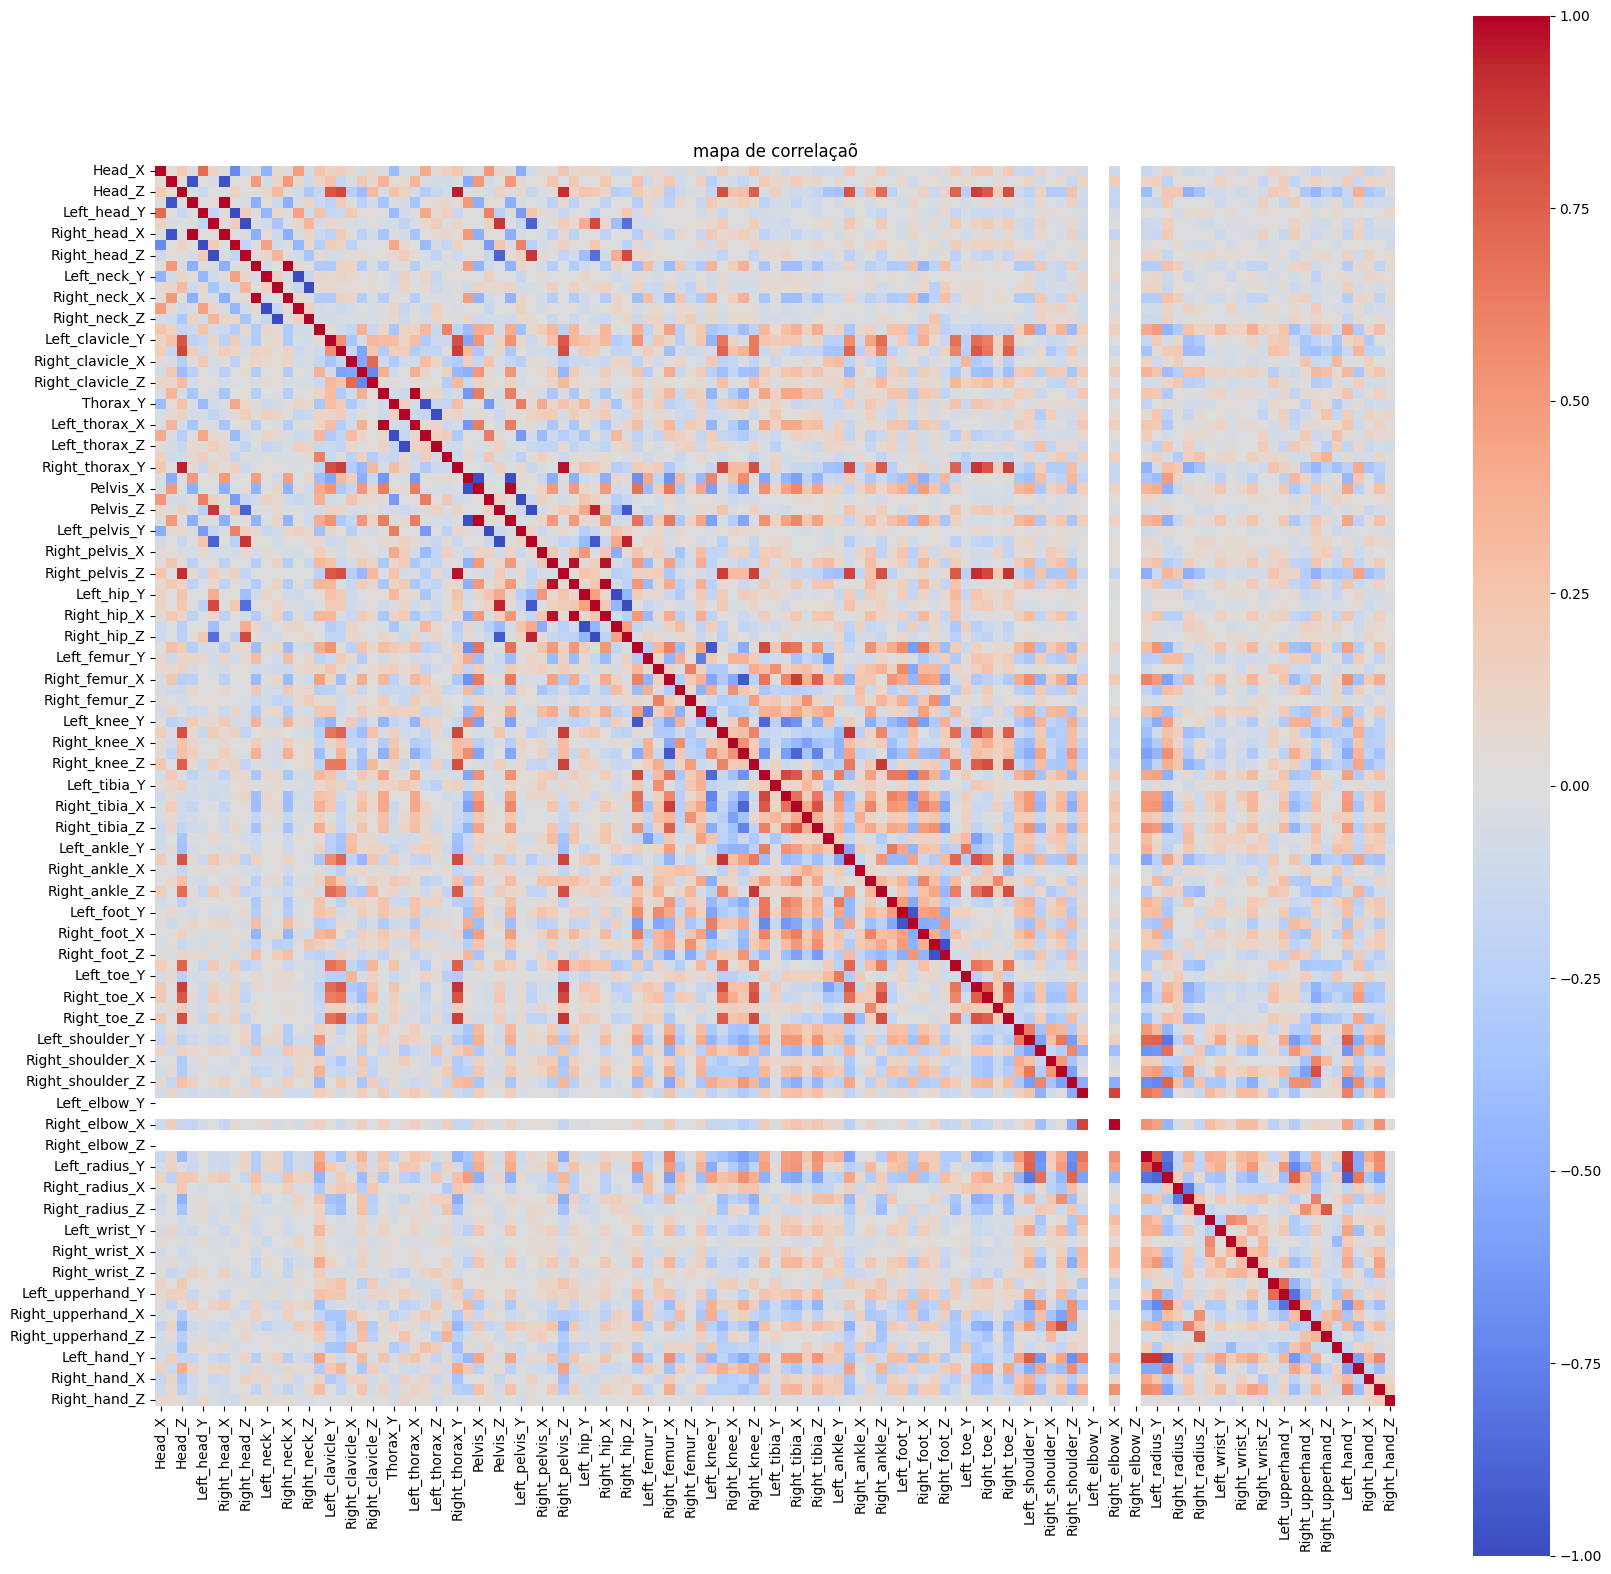

In [8]:
import seaborn as sns

import matplotlib.pyplot as plt


corr = df[ANGLE_COLS].corr()

# Plot heatmap
plt.figure(figsize=(20, 20))
sns.heatmap(corr, annot=False, cmap='coolwarm', square=True)
plt.title('mapa de correlaçaõ')
plt.show()

In [9]:
angle_variation = (
    df.groupby(['movement', 'subject', 'execution'])[ANGLE_COLS]
    .agg(lambda x: x.max() - x.min())   # amplitude de cada execução individual
    .groupby('movement')                  # agrupa por movimento
    .mean()                               # média das amplitudes
)

max_variation_per_exe = angle_variation.idxmax(axis=1)
max_value_per_exe     = angle_variation.max(axis=1)

result = pd.DataFrame({
    'max_angle'    : max_variation_per_exe,
    'max_variation': max_value_per_exe.round(2)
})
display(result)

,max_angle,max_variation
movement,,
1,Right_tibia_X,134.47
2,Right_tibia_X,91.44
3,Right_tibia_X,102.37
4,Right_femur_X,81.01
5,Right_tibia_X,111.47
6,Right_toe_Y,81.84
7,Right_radius_Z,154.78
8,Right_hand_X,71.32
9,Right_radius_Z,170.76
